In [27]:
import pandas as pd
from pathlib import Path

# Choose alpha here
alpha_value = 0.3
alpha_str = f"{alpha_value:.3f}"   # will format like 0.300

workspace_root = Path.cwd().parents[3]
results_dir = workspace_root / "policies" / "sjovik_sund" / "simulation_results"

# build filename using alpha
trip_requests_file = (
    results_dir
    / "current results"
    / f"sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_{alpha_str}_results_trip_requests_seed_1.csv"
)

bike_criticality = pd.read_csv(trip_requests_file)

print("Loaded:", trip_requests_file)


Loaded: c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\current results\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.300_results_trip_requests_seed_1.csv


In [28]:
#table of how many times each bike is used
bike_usage = bike_criticality['Bike ID'].value_counts()
print(bike_usage)

Bike ID
B656    34
B705    32
B677    32
B432    32
B256    32
        ..
B306     2
B178     2
B668     2
B766     1
B401     1
Name: count, Length: 763, dtype: int64


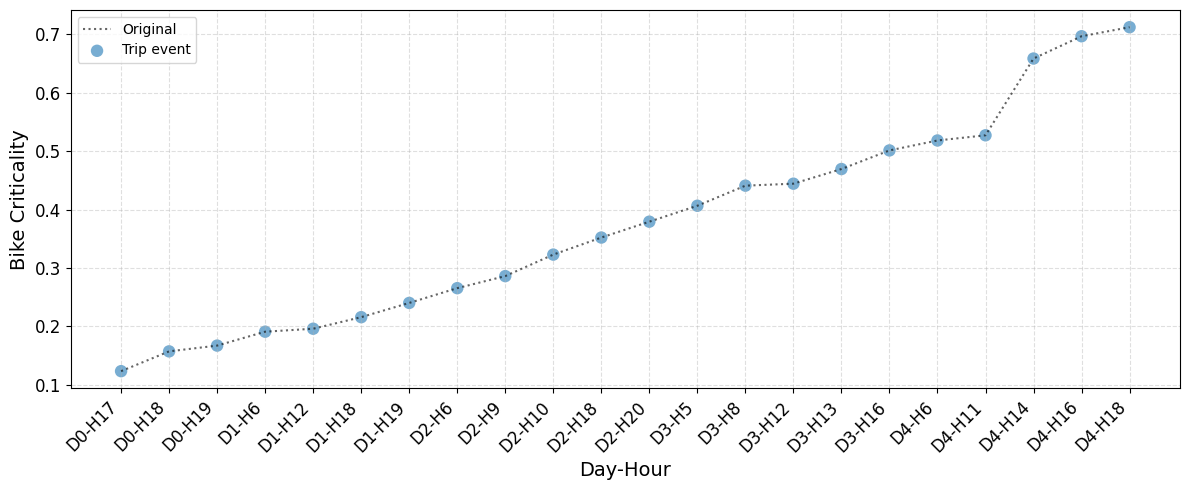

In [30]:
# plot the criticality for bike B744 for all hours and days
import pandas as pd
import matplotlib.pyplot as plt

bike_id = "B6"
df_bike = bike_criticality[bike_criticality["Bike ID"] == bike_id]

if df_bike.empty:
    raise ValueError(f"No rows found for bike {bike_id}")

# Aggregate by (Day, Hour) -> mean Bike Criticality
agg = (
    df_bike.groupby(["Day", "Hour"])["Bike Criticality"]
    .mean()
    .reset_index()
)

# Sort by time
agg_sorted = agg.sort_values(["Day", "Hour"]).reset_index(drop=True)

# Create labels like Dxx-Hxx
agg_sorted["Label"] = agg_sorted.apply(
    lambda row: f"D{int(row['Day'])}-H{int(row['Hour'])}", axis=1
)

# extract series
x = agg_sorted["Label"]
y = agg_sorted["Bike Criticality"]

plt.figure(figsize=(12, 5))

# ---- Original line (thin / dotted) ----
plt.plot(
    x, y,
    linestyle=":",
    color='black',
    alpha=0.6,
    label="Original"
)

# ---- Soft dots on top ----
plt.scatter(
    x, y,
    s=80,
    alpha=0.6,
    edgecolors="none",
    label="Trip event"
)

# make axe labels bigger
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# same with legend and axis names
plt.legend(fontsize=12)
plt.xlabel("Day-Hour", fontsize=14)
plt.ylabel("Bike Criticality", fontsize=14)
#plt.title(f"Bike Criticality timeline for {bike_id}")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
